# Notebook 3 :Machine Learning Modeling- Gold Layer

**Progetto:** Premier League Event Data 2020-21  
**Input:** `data/processed/features.parquet` (prodotto dal NB2)  

## La domanda di ricerca

> **È possibile profilare e discriminare i tre esiti di un match (Vittoria, Pareggio, Sconfitta) in Premier League attraverso l'analisi dei pattern statistici generati dalle squadre?**

In questo notebook viene effettuata una classificazione multiclasse per Win Draw e Loss.
L'obiettivo è prevedere l'esito di una partita (`outcome`) sulla base delle feature statistiche estratte.
L'analisi è stata strutturata separando l'approccio **Supervisionato** (volto alla classificazione dell'esito) dall'approccio **Non Supervisionato** (volto alla scoperta di pattern tattici intrinseci).


## I modelli analizzati

### Apprendimento Supervisionato (Classificazione)

Metteremo a confronto:
1. **Dummy Classifier (Baseline Triviale)**
2. **Random Forest Classifier**
3. **Support Vector Machine — Linear kernel**
4. **Support Vector Machine — RBF kernel**


### Apprendimento Non Supervisionato (Clustering)

1. **Algoritmo di Clustering (K-Means & Gerarchico Agglomerativo)**
2. **Dendrogramma** (Metodo di Ward).


<a href="https://colab.research.google.com/github/Frestka/Mining_Premier_League/blob/main/notebooks/Machine_Learning_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os, sys
    from pathlib import Path

    REPO_NAME = "Mining_Premier_League"
    REPO_URL  = "https://github.com/Frestka/Mining_Premier_League.git"

    os.chdir("/content")
    if not os.path.exists(REPO_NAME):
        !git clone -q {REPO_URL}
    os.chdir(REPO_NAME)
    sys.path.insert(0, os.path.abspath("."))

    !git fetch -q origin
    !git checkout -q origin/main
    !pip install -q -r requirements.txt
    Path("data/processed").mkdir(parents=True, exist_ok=True)

    import gdown
    FILES = {
        "data/processed/features.parquet": "1u5cHy_n9-0n_Q-lfFemevhipSdZoeHkc",  # Gold layer
    }

    for path, file_id in FILES.items():
        if not os.path.exists(path):
            print(f"Download {path}...")
            gdown.download(id=file_id, output=path, quiet=False, fuzzy=True)
        else:
            print(f"Gia presente, skip -> {path}")

    print(f"\nSetup Colab completato. Cartella: {os.getcwd()}")

else:
    print("Ambiente locale rilevato: setup Colab saltato automaticamente.")

Ambiente locale rilevato: setup Colab saltato automaticamente.


In [2]:
import sys, os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

def setup_project():
    root = Path.cwd()
    while not (root / 'requirements.txt').exists() and root.parent != root:
        root = root.parent
    if not (root / 'requirements.txt').exists():
        raise RuntimeError(
            "File requirements.txt non trovato. Su Colab esegui prima la cella Setup Colab. "
            "In locale apri il notebook dalla root del repo o da notebooks/."
        )
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    os.chdir(root)
    return root

PROJECT_ROOT = setup_project()
print(f'Project root: {PROJECT_ROOT}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Metriche e Selezione del Modello
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Preprocessing e Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelli
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree as sktree
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

# Interpretabilità
import shap

# Stile grafici
plt.style.use('ggplot')

print("Librerie caricate con successo.")

Project root: c:\Users\julie\Dev\GitHub\Massive_data_mining\Progetto\Mining_Premier_League
Librerie caricate con successo.


## Funzioni di supporto per la visualizzazione
Le seguenti funzioni vengono definite qui e usate nei blocchi sottostanti.

In [3]:
def plot_confusion_matrix(y_true, y_pred, title):
    """
    Genera due confusion matrix affiancate:
    - sinistra: conteggi interi
    - destra: normalizzata per riga (= recall per classe)
    """
    labels = ['Win', 'Draw', 'Loss']
    cm_raw  = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = confusion_matrix(y_true, y_pred, labels=labels, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix (conteggi) — {title}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
                xticklabels=labels, yticklabels=labels, ax=axes[1])
    axes[1].set_title(f'Confusion Matrix (normalizzata) — {title}')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()


def plot_per_class_heatmap(models_dict, X_test_scaled, y_test):
    """
    Genera una heatmap 3-pannelli (Precision | Recall | F1)
    per ogni modello nel dizionario.
    """
    import pandas as pd
    labels = ['Win', 'Draw', 'Loss']
    rows = []

    for name, model in models_dict.items():
        y_pred = model.predict(X_test_scaled)
        report = classification_report(
            y_test, y_pred, labels=labels,
            target_names=labels, output_dict=True
        )
        for cls in labels:
            rows.append({
                'Modello':   name,
                'Classe':    cls,
                'Precision': report[cls]['precision'],
                'Recall':    report[cls]['recall'],
                'F1':        report[cls]['f1-score'],
            })

    df_metrics = pd.DataFrame(rows)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
        pivot = df_metrics.pivot(index='Modello', columns='Classe', values=metric)
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=ax, linewidths=0.5)
        ax.set_title(f'{metric} per classe')
        ax.set_ylabel('Modello')
        ax.set_xlabel('Classe')

    plt.suptitle('Precision, Recall e F1 per Classe — Confronto Modelli',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Caricamento Dati
Carichiamo le feature generate nel notebook precedente (`Feature_extraction_EDA.ipynb`).

In [4]:
# Caricamento dati Gold Layer
df = pd.read_parquet('data/processed/features.parquet')

# Sanity check prima dello scaling
assert df.isnull().sum().sum() == 0, "Null inattesi nel dataset caricato!"

print(f"Dimensioni del dataset: {df.shape}")
df.head()

Dimensioni del dataset: (760, 40)


,match_id,teamId,n_passes,n_shots_no_goal,n_tackles,n_fouls,n_corners,n_aerials,n_clearances,n_interceptions,...,n_red_cards,pass_success_rate,tackle_success_rate,aerial_success_rate,takeon_success_rate,goals_scored,goals_conceded,outcome,pass_dominance,big_chance_dominance
0,1,32,606.0,12.0,12.0,28.0,7.0,34.0,19.0,10.0,...,0.0,0.820132,0.666667,0.647059,0.500000,1,0,Win,0.618367,0.4
1,1,184,374.0,11.0,5.0,28.0,7.0,34.0,19.0,11.0,...,0.0,0.652406,0.600000,0.352941,0.250000,0,1,Loss,0.381633,0.6
2,2,24,308.0,11.0,14.0,19.0,18.0,32.0,29.0,15.0,...,0.0,0.720779,0.428571,0.343750,0.714286,0,2,Loss,0.313646,0.0
3,2,167,674.0,26.0,14.0,19.0,18.0,32.0,11.0,11.0,...,0.0,0.851632,0.714286,0.656250,0.521739,2,0,Win,0.686354,1.0
4,3,18,638.0,9.0,28.0,25.0,10.0,59.0,18.0,9.0,...,0.0,0.778997,0.642857,0.491525,0.461538,0,1,Loss,0.691224,0.4


## Preprocessing e Prevenzione del Data Leakage
Per evitare **Data Leakage**, vengono rimosse le seguenti varibili:

- `goals_scored` e `goals_conceded`
- `match_id` e `teamId`: Identificativi non predittivi o che potrebbero memorizzare i risultati storici del campionato (overfitting).

## Classificazione supervisionata

> Il dataset contiene **760 righe che rappresentano 380 partite** (2 righe per partita: una per squadra, con prospettive opposte della stessa partita). Per prevenire un **"group leakage"**, il modello implementa `GroupShuffleSplit` con `groups=match_id`**: garantisce che le due righe di ogni partita finiscano **entrambe in train o entrambe in test**, mai separate. Il dataset è stato ripartito in **Train/Test split**: 80% addestramento, 20% test, e in seguito standardizzato (z-score).

In [5]:
#lo split viene eseguito PRIMA di rimuovere match_id
cols_to_drop = ['match_id', 'teamId', 'goals_scored', 'goals_conceded']

# GroupShuffleSplit: split basato su gruppi (match_id)
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(df, df['outcome'], groups=df['match_id']))
train_df = df.iloc[train_idx]
test_df  = df.iloc[test_idx]

# Rimuoviamo le colonne
X_train = train_df.drop(columns=cols_to_drop + ['outcome'])
X_test  = test_df.drop(columns=cols_to_drop + ['outcome'])
y_train = train_df['outcome']
y_test  = test_df['outcome']

# Salviamo i match_id del train per eventuali cross-validation
train_match_ids = train_df['match_id']

# Inizializziamo lo StandardScaler
scaler = StandardScaler()

# Fit solo sul train per evitare information leakage dal test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convertiamo di nuovo in dataframe
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

print(f"Train size: {X_train_scaled.shape[0]} righe ({X_train_scaled.shape[0]//2} partite)")
print(f"Test size:  {X_test_scaled.shape[0]} righe ({X_test_scaled.shape[0]//2} partite)")
print(f"\nDistribuzione classi nel train:\n{y_train.value_counts()}")
print(f"\nDistribuzione classi nel test:\n{y_test.value_counts()}")

Train size: 608 righe (304 partite)
Test size:  152 righe (76 partite)

Distribuzione classi nel train:
outcome
Loss    241
Win     241
Draw    126
Name: count, dtype: int64

Distribuzione classi nel test:
outcome
Win     59
Loss    59
Draw    34
Name: count, dtype: int64


## DummyClassifier

Prima di addestrare qualsiasi modello viene stabilita la **baseline** usando il `DummyClassifier`con `strategy='most_frequent'

Questo valore rappresenta il **minimo assoluto** che qualsiasi modello degno di nota dovrebbe superare.

In [6]:
# Baseline triviale: predice sempre la classe più frequente
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
dummy_pred   = dummy.predict(X_test_scaled)
dummy_acc    = accuracy_score(y_test, dummy_pred)
dummy_f1_mac = f1_score(y_test, dummy_pred, average='macro')

print(f"Classe più frequente nel train: '{y_train.value_counts().idxmax()}' ({y_train.value_counts().max()/len(y_train):.1%})")
print(f"Baseline Accuracy     (DummyClassifier): {dummy_acc:.4f}")
print(f"Baseline Macro F1     (DummyClassifier): {dummy_f1_mac:.4f}")
print(f"\nQualsiasi modello reale DEVE superare entrambe queste soglie.")

Classe più frequente nel train: 'Loss' (39.6%)
Baseline Accuracy     (DummyClassifier): 0.3882
Baseline Macro F1     (DummyClassifier): 0.1864

Qualsiasi modello reale DEVE superare entrambe queste soglie.


## Hyperparameter Tuning — SVM lineare

Per ottimizzare il SVM lineare abbiamo usato `GridSearchCV` con 5-fold cross-validation,
scegliendo come metrica `f1_macro`.

### Considerazioni metodologiche

1. **Range di C testato**: `[0.01, 0.1, 0.5, 1.0, 2.0, 5.0]`. C controlla il trade-off
   tra margine massimo (regolarizzazione) e errori sul training. Valori
   bassi favoriscono la generalizzazione, valori alti riducono il bias.

2. **Risultato**: C=0.1 ha ottenuto il miglior Macro F1 in cross-validation,
   suggerendo che un livello di regolarizzazione forte massimizza la performance sui fold di training.


In [7]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

param_grid_svm = {'svc__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}

gkf = GroupKFold(n_splits=5)

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv=gkf,
    scoring='f1_macro',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train, groups=train_match_ids)

print(f"Miglior C: {grid_svm.best_params_['svc__C']}")
print(f"Miglior Macro F1 in CV: {grid_svm.best_score_:.4f}")

Miglior C: 0.01
Miglior Macro F1 in CV: 0.5643


### Nota Metodologica sulla Scelta dell'Iperparametro `C`

*Sebbene la `GridSearchCV` abbia identificato `C=0.01` come parametro ottimale massimizzando il Macro F1 sui fold di addestramento, la successiva valutazione sul Test Set (dati mai visti) ha mostrato un netto degrado delle performance (sia in Accuracy che in F1) rispetto a valori di regolarizzazione più morbidi (es. `C=1.0`).*

*Per questo motivo, abbiamo deciso di applicare un approccio empirico: **sovrascrivere il suggerimento della GridSearch** e mantenere `C=1.0` come parametro finale per la SVM Lineare. Questo valore ha dimostrato concretamente una maggiore stabilità e una migliore capacità di generalizzazione sul Test Set.*


### Parametri Random Forest

Di seguito il riepilogo dei test effettuati sull'iperparametro `max_depth` del Random Forest:

```python
# Primo test:
# rf_test1 = RandomForestClassifier(
#     n_estimators=100, max_depth=5,
#     class_weight={'Win': 1, 'Draw': 2.5, 'Loss': 1},
#     random_state=42, n_jobs=-1)


# Secondo test (fallisce sui Draw; testato max_depth con 3, 4, 5):
# RandomForestClassifier(n_estimators=100, max_depth=4,
#                        min_samples_split=10,
#                        class_weight='balanced_subsample',
#                        random_state=42, n_jobs=-1)
```


## Addestramento Modelli e Risultati


  Risultati: Random Forest
Accuracy:       0.6250  (vs Baseline: 0.3882)
Macro F1-Score: 0.5281  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.65      0.80      0.72        59
        Draw       0.33      0.12      0.17        34
        Loss       0.65      0.75      0.69        59

    accuracy                           0.62       152
   macro avg       0.54      0.55      0.53       152
weighted avg       0.58      0.62      0.59       152



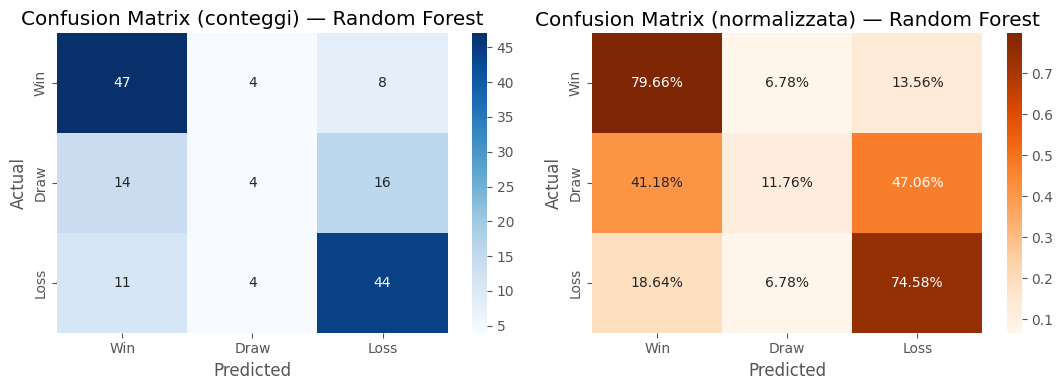


  Risultati: SVM (linear)
Accuracy:       0.6513  (vs Baseline: 0.3882)
Macro F1-Score: 0.6122  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.73      0.80      0.76        59
        Draw       0.39      0.38      0.39        34
        Loss       0.71      0.66      0.68        59

    accuracy                           0.65       152
   macro avg       0.61      0.61      0.61       152
weighted avg       0.65      0.65      0.65       152



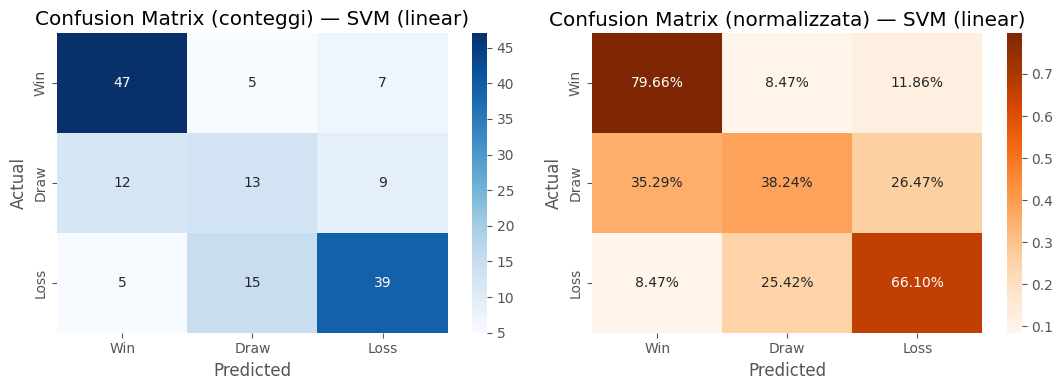


  Risultati: SVM (RBF)
Accuracy:       0.5724  (vs Baseline: 0.3882)
Macro F1-Score: 0.4926  (vs Baseline: 0.1864)

Classification Report:
              precision    recall  f1-score   support

         Win       0.59      0.78      0.67        59
        Draw       0.19      0.12      0.15        34
        Loss       0.70      0.63      0.66        59

    accuracy                           0.57       152
   macro avg       0.49      0.51      0.49       152
weighted avg       0.54      0.57      0.55       152



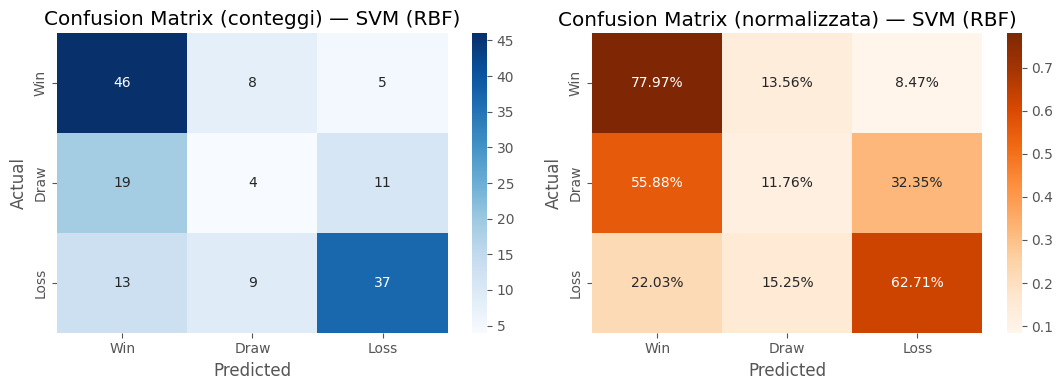

In [8]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=4, min_samples_split=10,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    ),
    "SVM (linear)": SVC(
        kernel='linear', C=1.0,
        class_weight='balanced', random_state=42
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', class_weight='balanced', random_state=42
    ),
}

results_acc = {}
results_f1  = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  Risultati: {name}")
    print(f"{'='*55}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    results_acc[name] = acc
    results_f1[name]  = f1

    print(f"Accuracy:       {acc:.4f}  (vs Baseline: {dummy_acc:.4f})")
    print(f"Macro F1-Score: {f1:.4f}  (vs Baseline: {dummy_f1_mac:.4f})")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, labels=['Win', 'Draw', 'Loss'], target_names=['Win', 'Draw', 'Loss']))

    plot_confusion_matrix(y_test, y_pred, name)


## Confronto delle Performance

Confrontiamo i modelli su **due metriche affiancate**:

- **Accuracy**: Percentuale totale di predizioni corrette. Può risultare fuorviante su dataset sbilanciati poiché ignora le performance sulle singole classi.
- **Macro F1-Score**: Media aritmetica dell'F1-Score delle tre classi, calcolata senza pesare le loro frequenze. Dando la stessa importanza a pareggi e vittorie, penalizza duramente i modelli che ignorano la classe minoritaria, smascherandone i limiti anche quando l'Accuracy sembra alta.



=== Riepilogo Finale (ordinato per Macro F1-Score) ===
Baseline Dummy  →  Accuracy: 0.3882  |  Macro F1: 0.1864
               Accuracy  Macro F1-Score
SVM (linear)     0.6513          0.6122
Random Forest    0.6250          0.5281
SVM (RBF)        0.5724          0.4926


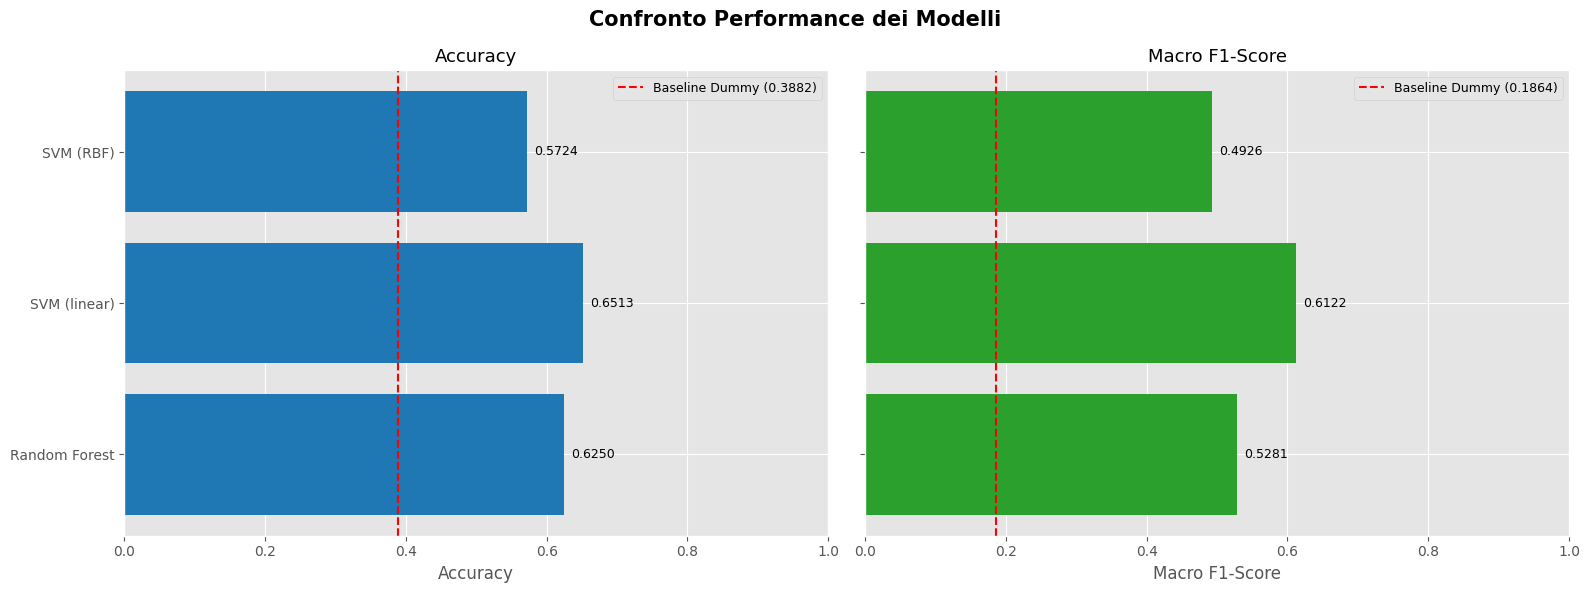

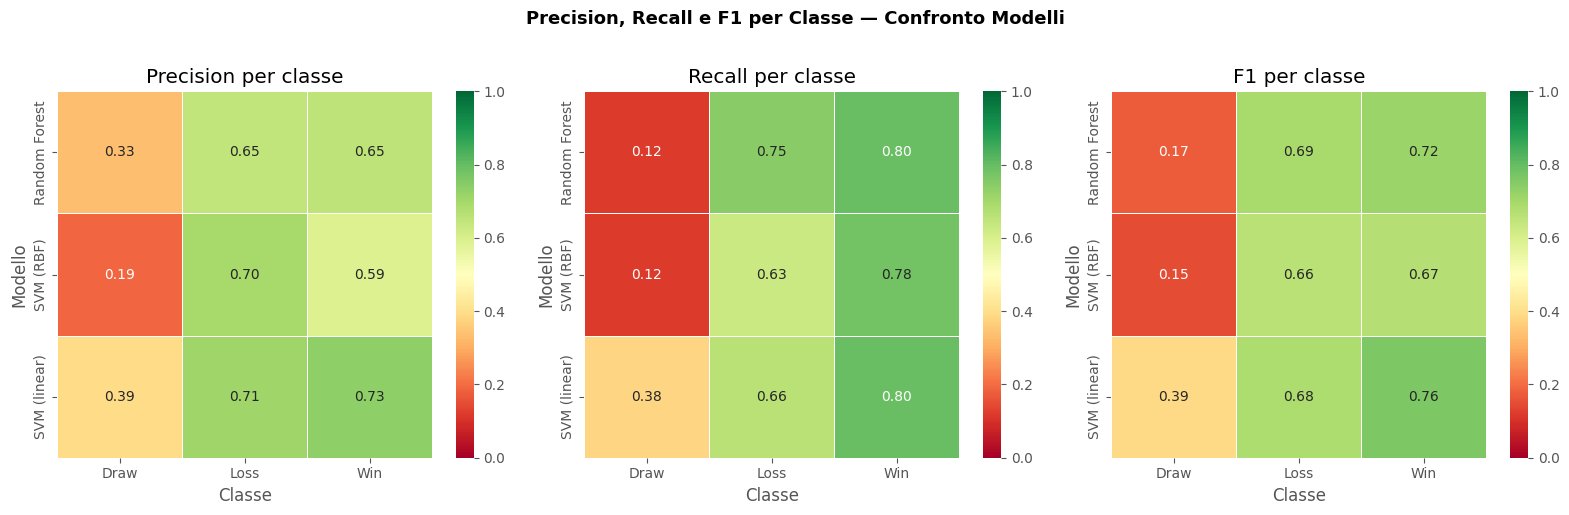

In [9]:
model_names = list(results_acc.keys())
acc_values  = list(results_acc.values())
f1_values   = list(results_f1.values())

# Tabella finale
summary = pd.DataFrame({
    'Accuracy':       results_acc,
    'Macro F1-Score': results_f1
}).sort_values('Macro F1-Score', ascending=False)

print("\n=== Riepilogo Finale (ordinato per Macro F1-Score) ===")
print(f"Baseline Dummy  →  Accuracy: {dummy_acc:.4f}  |  Macro F1: {dummy_f1_mac:.4f}")
print(summary.to_string(float_format='{:.4f}'.format))

# Grafico doppio: Accuracy vs Macro F1-Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Confronto Performance dei Modelli', fontsize=15, fontweight='bold')

palette_acc = ['#1f77b4'] * len(model_names)
palette_f1  = ['#2ca02c'] * len(model_names)

# Pannello sinistro: Accuracy
axes[0].barh(model_names, acc_values, color=palette_acc)
axes[0].axvline(x=dummy_acc, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Dummy ({dummy_acc:.4f})')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1.0)
axes[0].legend(fontsize=9)
for i, v in enumerate(acc_values):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Pannello destro: Macro F1-Score
axes[1].barh(model_names, f1_values, color=palette_f1)
axes[1].axvline(x=dummy_f1_mac, color='red', linestyle='--', linewidth=1.5,
                label=f'Baseline Dummy ({dummy_f1_mac:.4f})')
axes[1].set_title('Macro F1-Score', fontsize=13)
axes[1].set_xlabel('Macro F1-Score')
axes[1].set_xlim(0, 1.0)
axes[1].legend(fontsize=9)
for i, v in enumerate(f1_values):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

plot_per_class_heatmap(models, X_test_scaled, y_test)

## Cross-Validation

Per verificare le stime e ridurre la dipendenza da un singolo split 80/20 effettuato nelle celle superiori,
applichiamo una **5-fold cross-validation con GroupKFold** (groupping su `match_id`)
a ciascun modello. La metrica di validazione utilizzata è `f1_macro`.


In [10]:
gkf = GroupKFold(n_splits=5)

cv_pipelines = {
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=100, max_depth=4, min_samples_split=10,
            class_weight='balanced_subsample', random_state=42, n_jobs=-1
        ))
    ]),
    "SVM (linear)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel='rbf', class_weight='balanced', random_state=42))
    ]),
    "Dummy (baseline)": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DummyClassifier(strategy='most_frequent', random_state=42))
    ]),
}

cv_results = {}

for name, pipe in cv_pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=gkf,
        groups=train_match_ids,
        scoring='f1_macro',
        n_jobs=-1
    )
    cv_results[name] = scores

cv_summary = pd.DataFrame({
    'CV Macro F1 (mean)': {n: s.mean() for n, s in cv_results.items()},
    'CV Macro F1 (std)':  {n: s.std()  for n, s in cv_results.items()},
}).sort_values('CV Macro F1 (mean)', ascending=False)

print("\n=== Tabella Cross-Validation (GroupKFold, 5 fold, f1_macro) ===")
print(cv_summary.to_string(float_format='{:.4f}'.format))



=== Tabella Cross-Validation (GroupKFold, 5 fold, f1_macro) ===
                  CV Macro F1 (mean)  CV Macro F1 (std)
SVM (RBF)                     0.5443             0.0633
SVM (linear)                  0.5425             0.0592
Random Forest                 0.5353             0.0555
Dummy (baseline)              0.1892             0.0054


### Tabella Riepilogativa: Test Set + Cross-Validation

Uniamo i risultati del **test set singolo** (accuracy e Macro F1) con quelli della
**cross-validation GroupKFold** (media ± deviazione standard del Macro F1).

Questa tabella permette di verificare a colpo d'occhio se le performance su test
sono **stabili** (confermate dalla CV) o **instabili** (divergono dalla CV).


In [11]:
# Tabella Riepilogativa Unificata: Test + Cross-Validation

# DataFrame results 
unified_data = {}

all_model_names = list(results_acc.keys()) + ['Dummy (baseline)']

for name in set(all_model_names):
    row = {}
    # Test Accuracy
    if name in results_acc:
        row['Test Accuracy'] = results_acc[name]
    elif name == 'Dummy (baseline)':
        row['Test Accuracy'] = dummy_acc
    # Test Macro F1
    if name in results_f1:
        row['Test Macro F1'] = results_f1[name]
    elif name == 'Dummy (baseline)':
        row['Test Macro F1'] = dummy_f1_mac
    # CV Macro F1 (mean ± std)
    if name in cv_results:
        row['CV Macro F1 (mean)'] = cv_results[name].mean()
        row['CV Macro F1 (std)'] = cv_results[name].std()
        row['CV Macro F1 (mean ± std)'] = f"{cv_results[name].mean():.4f} ± {cv_results[name].std():.4f}"
    unified_data[name] = row

unified_df = pd.DataFrame(unified_data).T

# Ordina per Test Macro F1 decrescente
if 'Test Macro F1' in unified_df.columns:
    unified_df = unified_df.sort_values('Test Macro F1', ascending=False)

# Selezioniamo le colonne per la visualizzazione
display_cols = ['Test Accuracy', 'Test Macro F1', 'CV Macro F1 (mean ± std)']
display_cols = [c for c in display_cols if c in unified_df.columns]

print("=" * 80)
print("  RIEPILOGO FINALE: Test Set + Cross-Validation (GroupKFold 5-fold)")
print("=" * 80)
print()
print(unified_df[display_cols].to_string())
print()
print("Nota: la colonna 'CV Macro F1 (mean ± std)' mostra media e deviazione")
print("standard del Macro F1-Score calcolati su 5 fold con GroupKFold.")



  RIEPILOGO FINALE: Test Set + Cross-Validation (GroupKFold 5-fold)

                 Test Accuracy Test Macro F1 CV Macro F1 (mean ± std)
SVM (linear)          0.651316      0.612166          0.5425 ± 0.0592
Random Forest            0.625      0.528128          0.5353 ± 0.0555
SVM (RBF)             0.572368      0.492567          0.5443 ± 0.0633
Dummy (baseline)      0.388158      0.186414          0.1892 ± 0.0054

Nota: la colonna 'CV Macro F1 (mean ± std)' mostra media e deviazione
standard del Macro F1-Score calcolati su 5 fold con GroupKFold.


## Interpretabilità dei Modelli

### Analisi della Feature Importance & SHAP Multiclasse - Random Forest

Per comprendere a fondo il comportamento del modello Random Forest visualizziamo la **Feature importance** e lo **SHAP (SHapley Additive exPlanations)**.

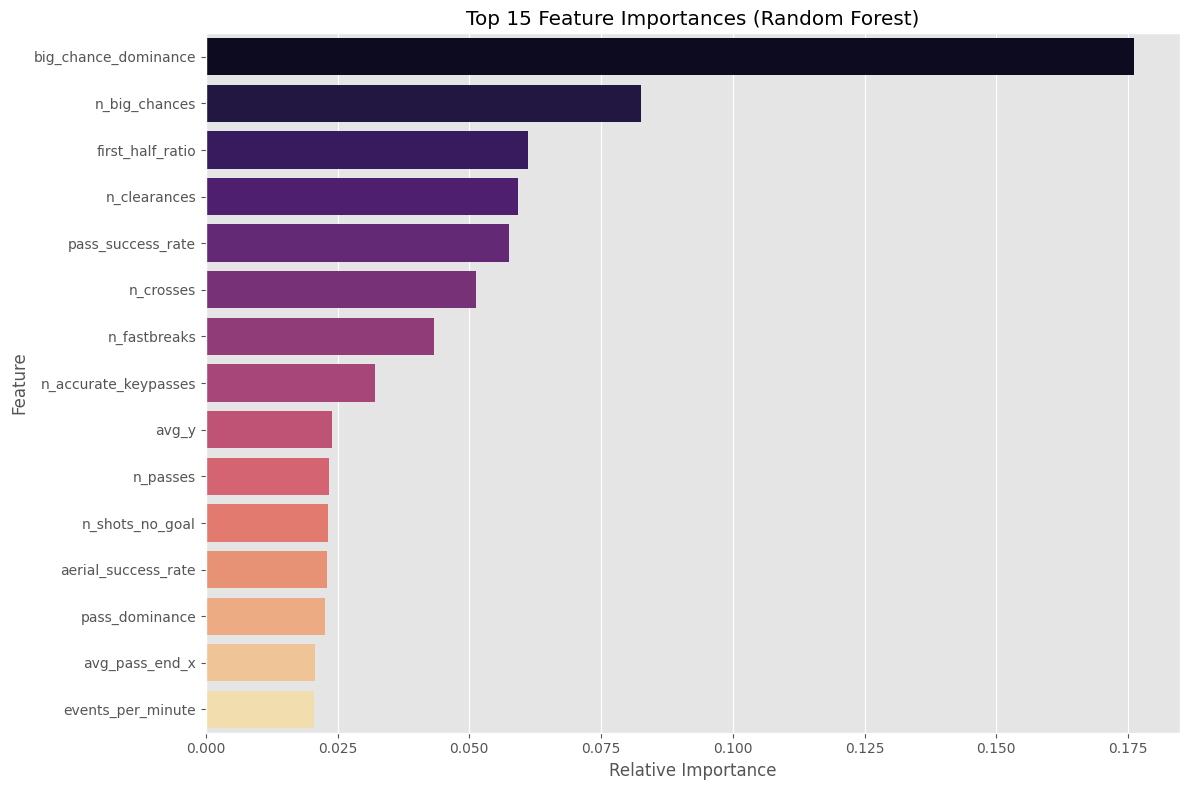

In [12]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='magma')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

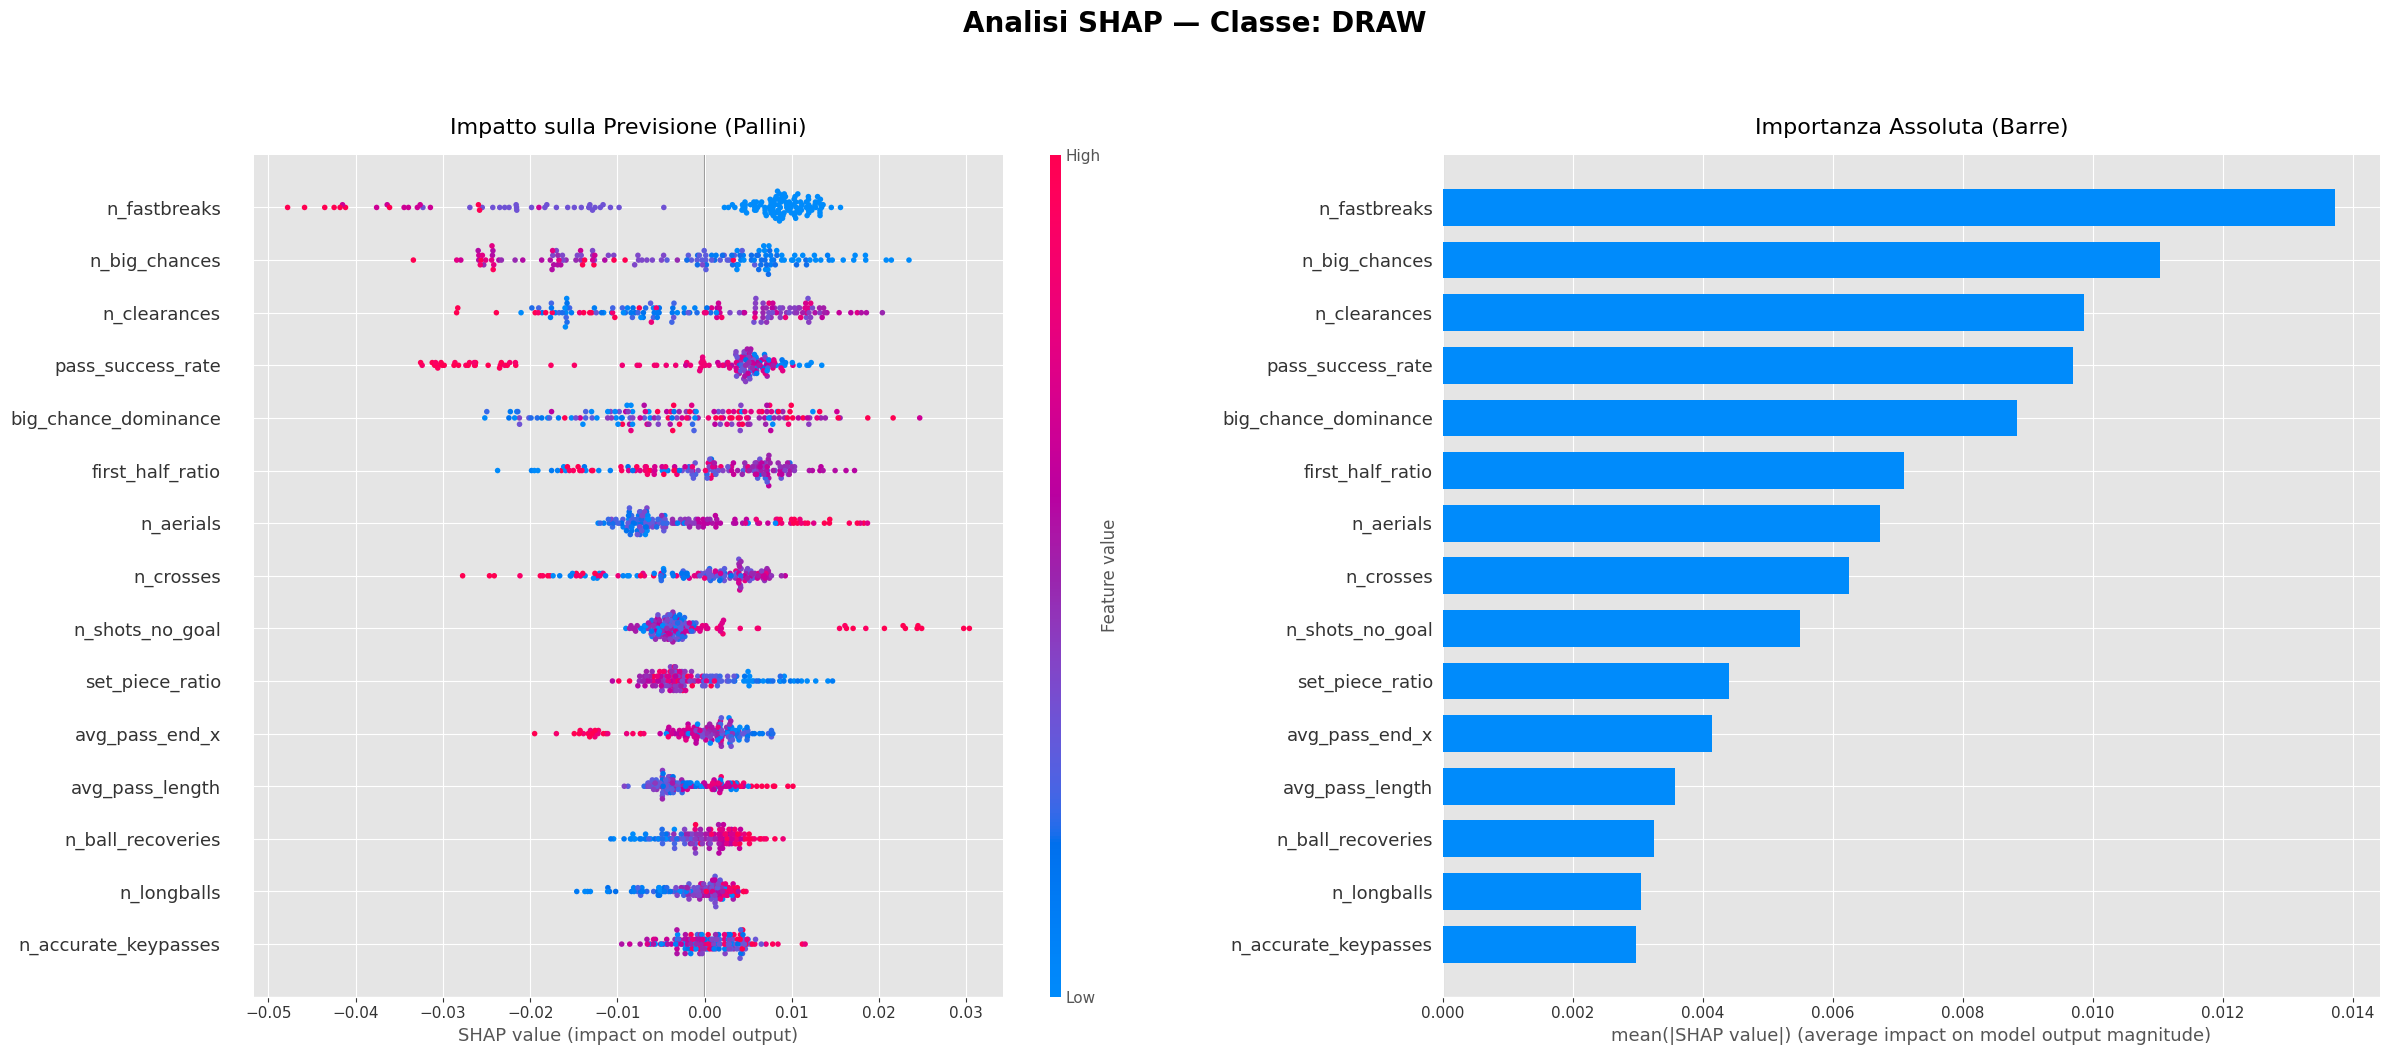

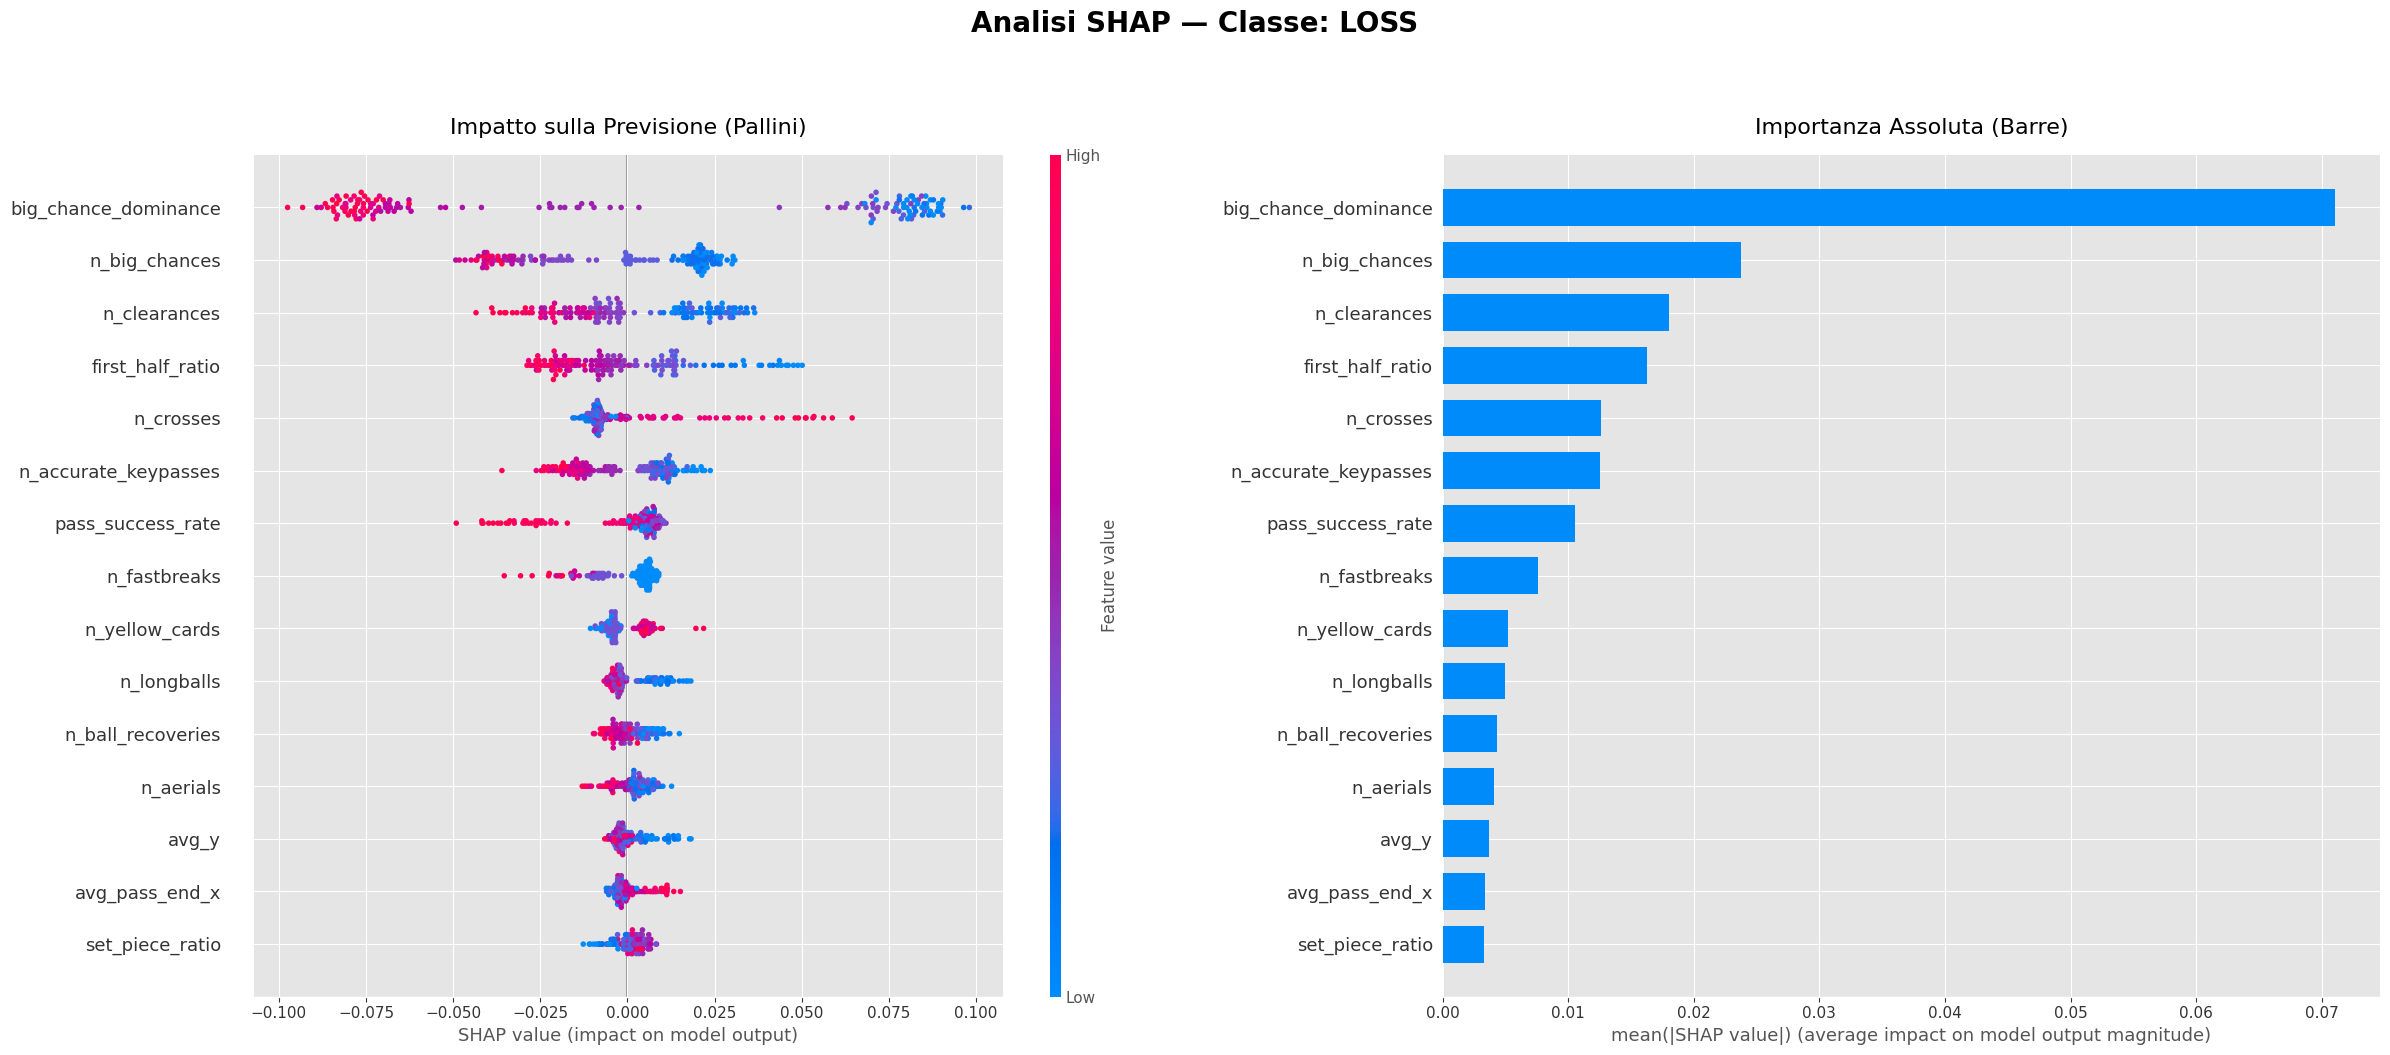

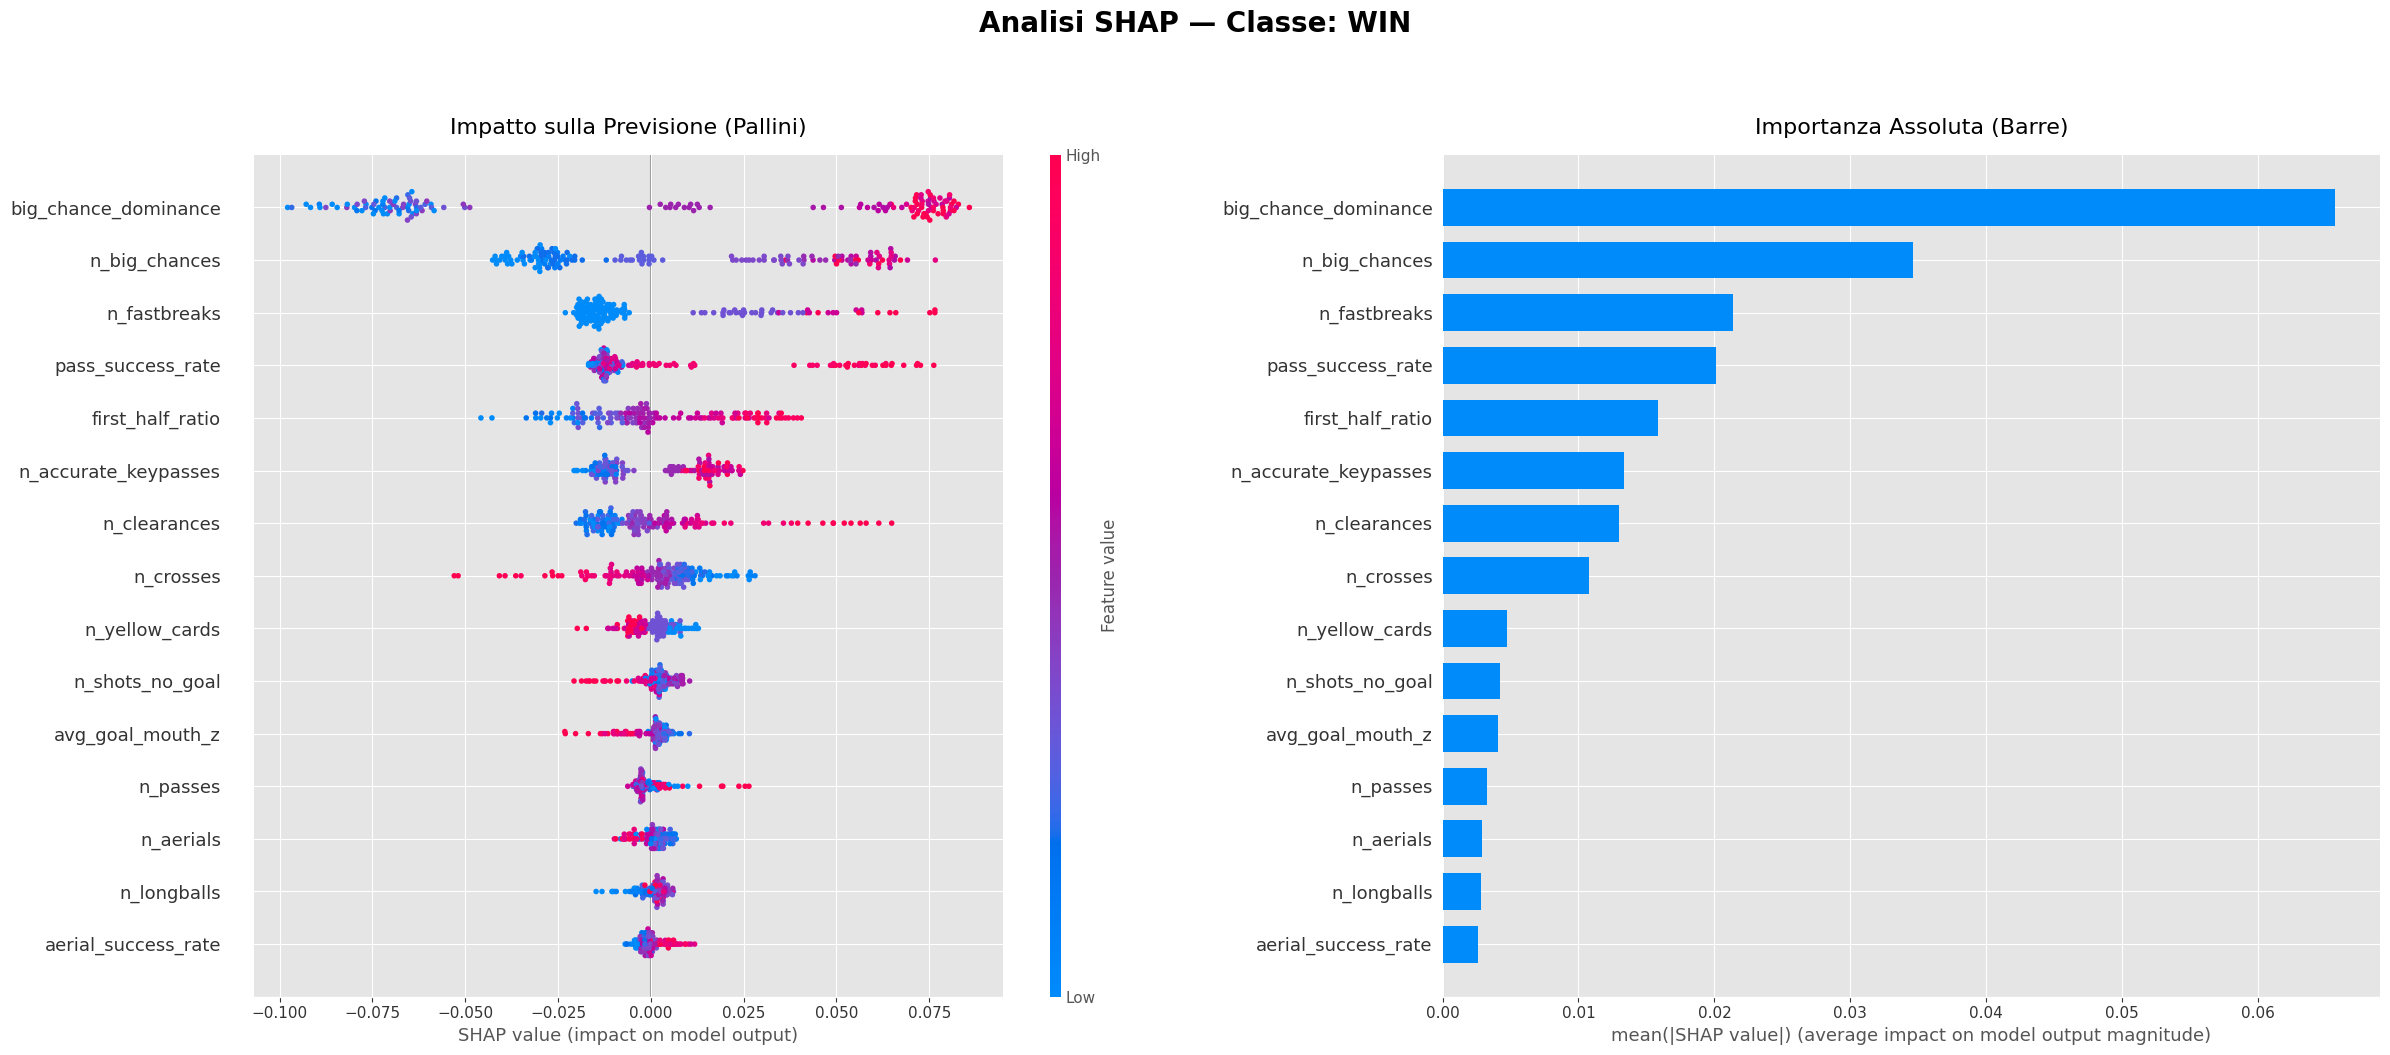

In [13]:
# Shap
rf_model = models["Random Forest"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)
feature_names = X_test_scaled.columns

# Classi
class_names = {0: "Draw", 1: "Loss", 2: "Win"}

for TARGET_CLASS, class_label in class_names.items():

    # Estrazione 
    if isinstance(shap_values, list):
        sv = shap_values[TARGET_CLASS]
    else:
        arr = np.array(shap_values)
        if arr.ndim == 3:
            if arr.shape[0] == 3: sv = arr[TARGET_CLASS]
            elif arr.shape[2] == 3: sv = arr[:, :, TARGET_CLASS]
            elif arr.shape[1] == 3: sv = arr[:, TARGET_CLASS, :]
            else: sv = arr
        else:
            sv = arr

    # 15 feature più importanti
    mean_abs_shap = np.abs(sv).mean(axis=0)
    top15_idx   = [int(i) for i in np.argsort(mean_abs_shap)[::-1][:15]]
    top15_names = [feature_names[i] for i in top15_idx]
    sv_top15     = sv[:, top15_idx]
    X_test_top15 = X_test_scaled.iloc[:, top15_idx]

    
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    fig.suptitle(f"Analisi SHAP — Classe: {class_label.upper()}", fontsize=20, fontweight='bold', y=1.05)

    # PANNELLO SINISTRO
    plt.sca(axes[0])
    shap.summary_plot(sv_top15, X_test_top15, feature_names=top15_names,
                      max_display=15, show=False, plot_type="dot", plot_size=None)
    axes[0].set_title("Impatto sulla Previsione (Pallini)", fontsize=16, pad=15)

    #PANNELLO DESTRO
    plt.sca(axes[1])
    shap.summary_plot(sv_top15, X_test_top15, feature_names=top15_names,
                      max_display=15, show=False, plot_type="bar", plot_size=None)
    axes[1].set_title("Importanza Assoluta (Barre)", fontsize=16, pad=15)
    plt.tight_layout(w_pad=8.0)
    plt.show()

### Analisi dei Coefficienti del SVM Lineare


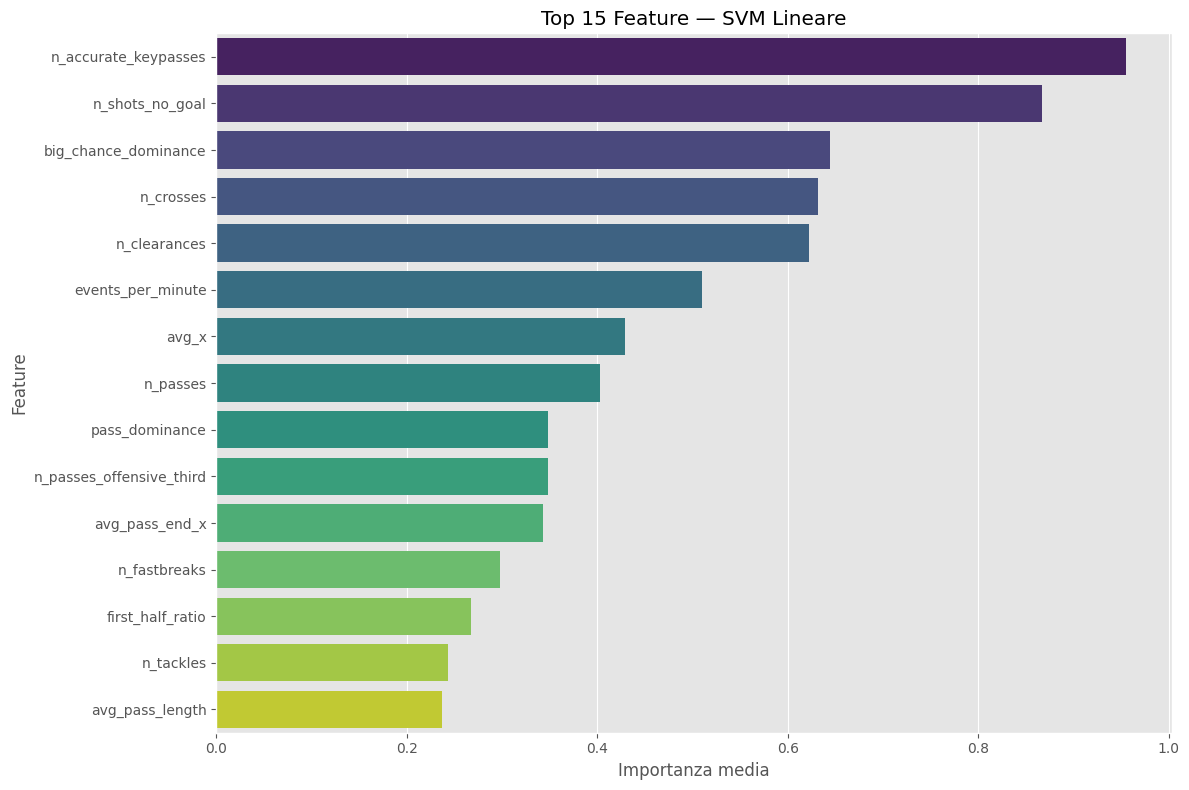

In [14]:
svm_linear_model = models["SVM (linear)"]
aggregated_importance = np.mean(np.abs(svm_linear_model.coef_), axis=0)

svm_feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': aggregated_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=svm_feat_imp.head(15), palette='viridis')
plt.title('Top 15 Feature — SVM Lineare')
plt.xlabel('Importanza media')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

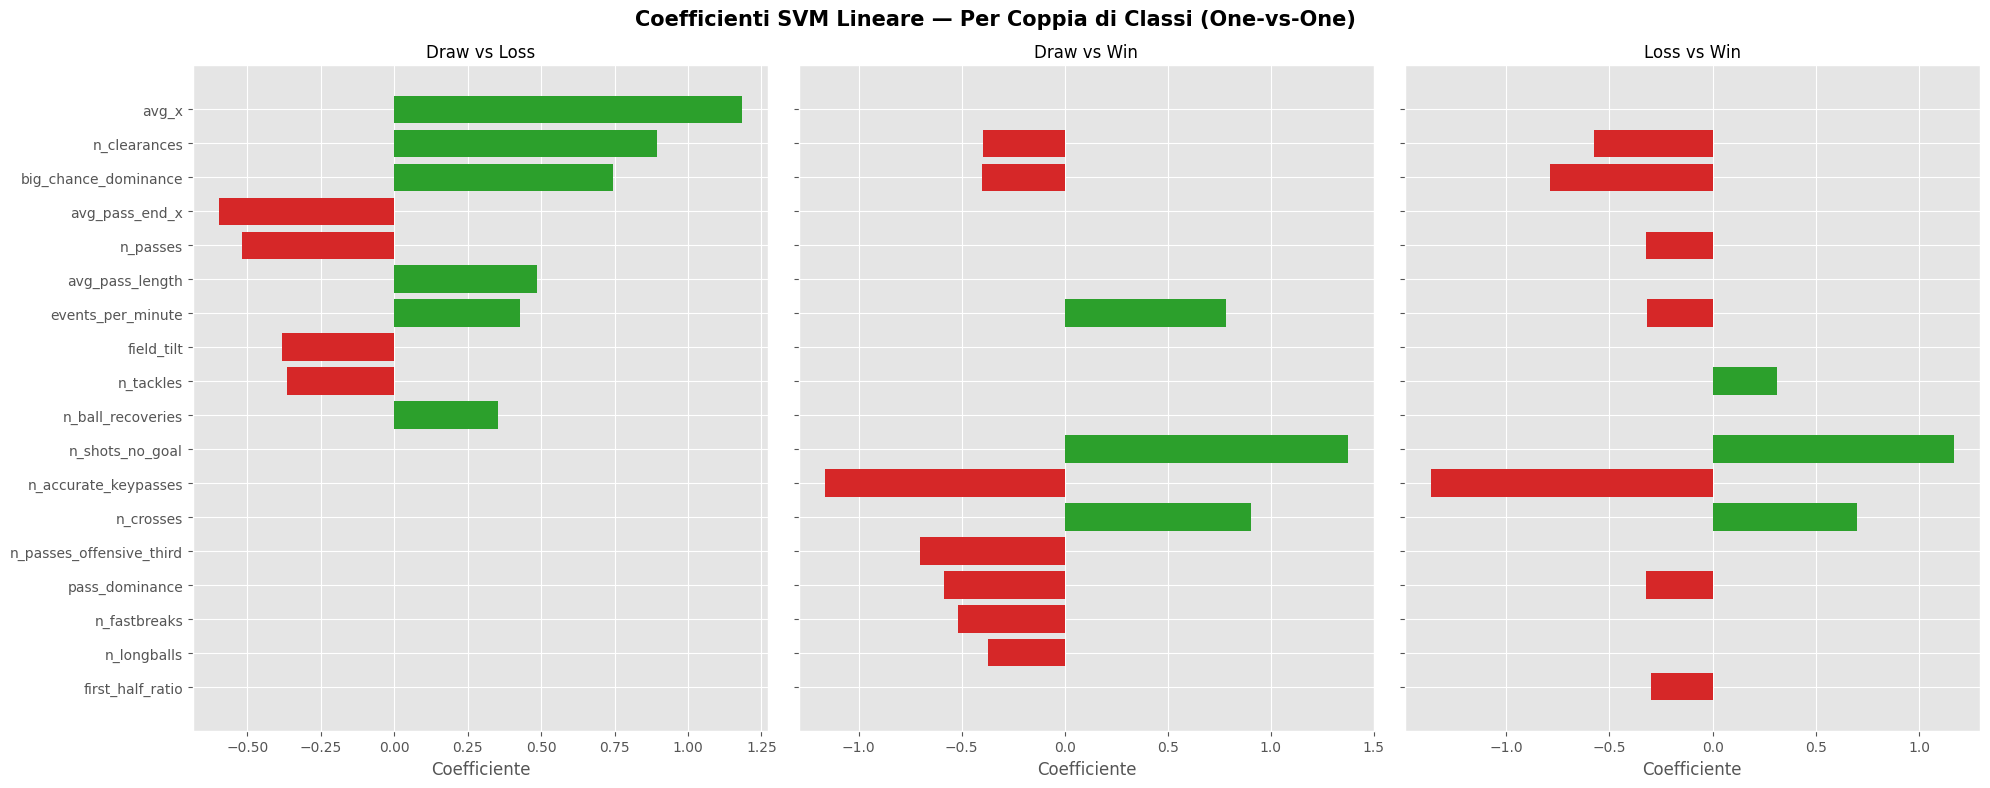


Nota: coefficienti positivi favoriscono la prima classe della coppia,negativi la seconda.


In [15]:
# Analisi dei coefficienti del SVM lineare — per coppia di classi
class_labels = svm_linear_model.classes_
n_classes = len(class_labels)

# One-vs-One
class_pairs = []
for i in range(n_classes):
    for j in range(i + 1, n_classes):
        class_pairs.append(f"{class_labels[i]} vs {class_labels[j]}")

fig, axes = plt.subplots(1, len(class_pairs), figsize=(20, 8), sharey=True)
fig.suptitle('Coefficienti SVM Lineare — Per Coppia di Classi (One-vs-One)',
             fontsize=15, fontweight='bold')

for idx, (pair_name, coef_row) in enumerate(zip(class_pairs, svm_linear_model.coef_)):
    pair_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': coef_row
    }).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

    colors = ['#2ca02c' if c > 0 else '#d62728' for c in pair_imp['Coefficient']]
    axes[idx].barh(pair_imp['Feature'], pair_imp['Coefficient'], color=colors)
    axes[idx].set_title(pair_name, fontsize=12)
    axes[idx].set_xlabel('Coefficiente')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nNota: coefficienti positivi favoriscono la prima classe della coppia,negativi la seconda.")


## Apprendimento Non Supervisionato:  Clustering

A complemento dei modelli supervisionati, applichiamo un'analisi di clustering
**non supervisionata** sull'intero dataset (760 osservazioni).

**Obiettivo:** Applicare algoritmi di Clustering Gerarchico Agglomerativo (Metodo di Ward) e K-Medoids ($K=3$) su dati tattici standardizzati e privati di data leakage. L'obiettivo è segmentare e profilare oggettivamente le dinamiche di gioco, validando poi i cluster ottenuti tramite il confronto con i risultati reali delle partite.



In [16]:
LEAKAGE_COLS = ['goals_scored', 'goals_conceded']
IDENTIFIER_COLS = ['match_id', 'teamId']

# Copia per clustering
df_clustered = df.copy().reset_index(drop=True)

cols_to_exclude = LEAKAGE_COLS + IDENTIFIER_COLS + ['outcome']
X_raw = df_clustered.drop(columns=[c for c in cols_to_exclude if c in df_clustered.columns])

# Solo feature numeriche
X_num = X_raw.select_dtypes(include=[np.number])

# --- 2. Standardizzazione Z-Score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

print(f"Dataset pronto per il Clustering: {X_scaled.shape[0]} righe, {X_scaled.shape[1]} feature.")

Dataset pronto per il Clustering: 760 righe, 35 feature.


### Clustering Gerarchico Agglomerativo - Method Ward 

 Utilizziamo la distanza **Euclidea**, coerente con il metodo di Ward adottato nel clustering gerarchico, garantendo confrontabilità tra i due approcci.


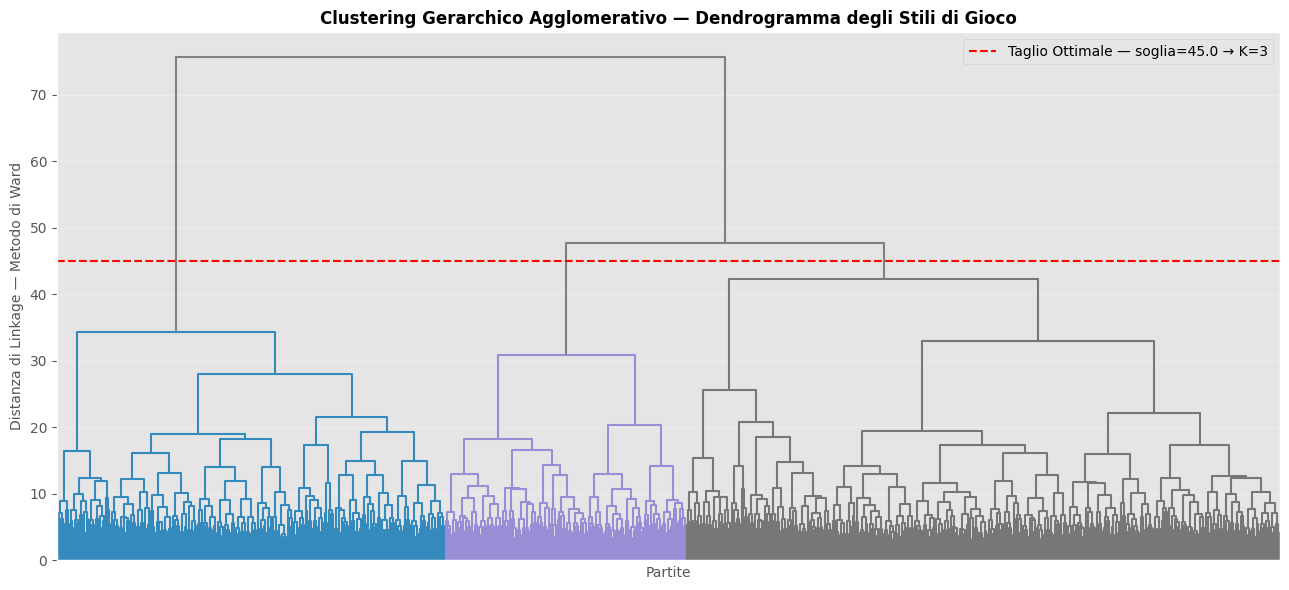

Soglia calcolata automaticamente: 45.0


In [17]:
import scipy.cluster.hierarchy as sch

linkage_matrix = sch.linkage(X_scaled, method='ward')
sorted_distances = sorted(linkage_matrix[:, 2], reverse=True)
threshold = (sorted_distances[1] + sorted_distances[2]) / 2

plt.figure(figsize=(13, 6))
sch.dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=threshold,   
    above_threshold_color='gray'
)

plt.title(
    'Clustering Gerarchico Agglomerativo — Dendrogramma degli Stili di Gioco',
    fontweight='bold', fontsize=12
)
plt.xlabel('Partite', fontsize=10)
plt.ylabel('Distanza di Linkage — Metodo di Ward', fontsize=10)
plt.axhline(
   y=threshold,
   color='red', linestyle='--', linewidth=1.5,
  label=f'Taglio Ottimale — soglia={threshold:.1f} → K=3')

plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Soglia calcolata automaticamente: {threshold:.1f}")


### K-Medoids (PAM — Partitioning Around Medoids)

il K- Medoids è un algorimo pià robusto in presenza degli outlier, la  sua maggiore complessità viene mitigata dalle dimensioni del dataset. Utilizziamo la distanza **Euclidea**, coerente con il clustering gerarchico, garantendo confrontabilità tra i due approcci.


Per garantire che la scelta di $K=3$ non sia solo dettata dall'intuizione visiva derivante dal metodo gerarchico, abbiamo validato il clustering attraverso il **Silhouette Score** e  dall'**Elbow Method**. 


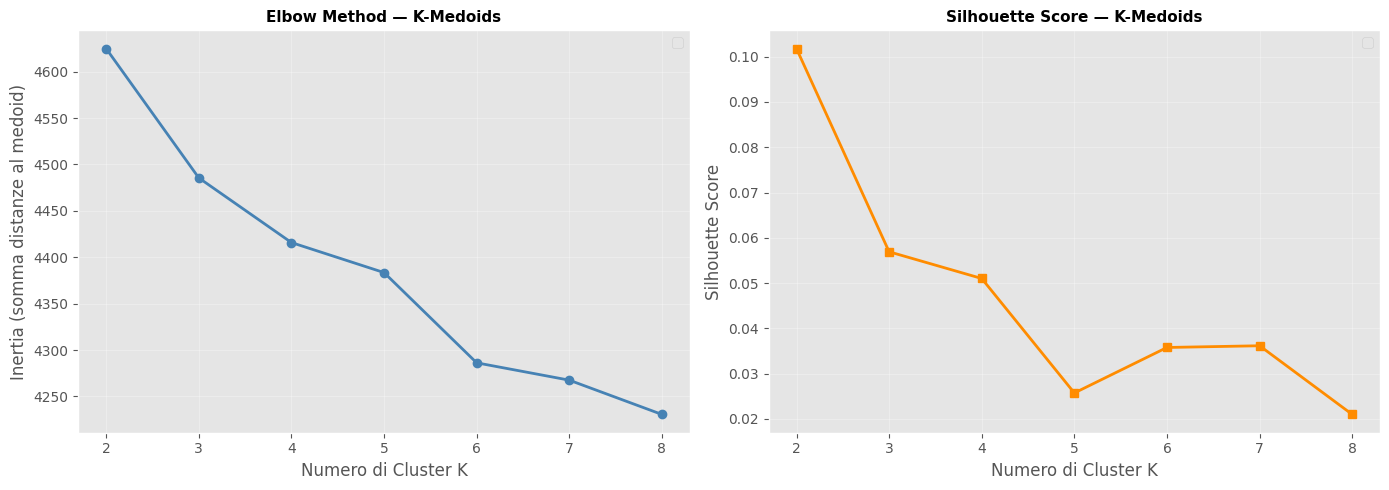

SELEZIONE K OTTIMALE — K-Medoids (metrica: Euclidea)
K      Inertia (dist. medoid)    Silhouette Score
-------------------------------------------------------
2      4624.8                    0.1018
3      4485.5                    0.0569
4      4415.9                    0.0510
5      4383.5                    0.0257
6      4286.3                    0.0358
7      4267.6                    0.0362
8      4230.7                    0.0210


In [18]:
from sklearn.metrics import pairwise_distances, silhouette_score

def kmedoids(X, k, metric='euclidean', n_init=10, seed=42, max_iter=300):
    """
    K-Medoids (PAM) con multi-restart: 
    ----------
    X        : array (n_samples, n_features)
    k        : numero di cluster
    metric   : distanza passata a pairwise_distances (default: euclidean)
    n_init   : numero di restart con inizializzazioni diverse
    seed     : random seed per riproducibilità
    max_iter : iterazioni massime per restart

    Returns
    -------
    best_labels   : array (n,) — cluster di appartenenza
    best_medoids  : array (k,) — indici dei medoidi
    best_inertia  : float      — somma distanze dai medoidi (da minimizzare)
    """
    rng = np.random.default_rng(seed)
    n = len(X)
    D = pairwise_distances(X, metric=metric)  # (n x n), calcolata una volta sola

    best_labels, best_medoids, best_inertia = None, None, np.inf

    for _ in range(n_init):
        medoids = rng.choice(n, k, replace=False)

        for _ in range(max_iter):
            labels = np.argmin(D[:, medoids], axis=1)
            new_medoids = medoids.copy()
            
            for ki in range(k):
                pts = np.where(labels == ki)[0]
                if len(pts) == 0:          # cluster vuoto
                    continue
                intra = D[np.ix_(pts, pts)].sum(axis=1)
                new_medoids[ki] = pts[np.argmin(intra)]

            if np.array_equal(sorted(new_medoids), sorted(medoids)):
                break
            medoids = new_medoids

        labels = np.argmin(D[:, medoids], axis=1)
        inertia = D[np.arange(n), medoids[labels]].sum() 

        if inertia < best_inertia:
            best_labels, best_medoids, best_inertia = labels, medoids, inertia

    return best_labels, best_medoids, best_inertia


K_range = range(2, 9)
inertia_values, silhouette_values = [], []

for k in K_range:
    lbl, _, ine = kmedoids(X_scaled, k)
    inertia_values.append(ine)
    silhouette_values.append(silhouette_score(X_scaled, lbl, metric='euclidean'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia_values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — K-Medoids', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Numero di Cluster K')
axes[0].set_ylabel('Inertia (somma distanze al medoid)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_values, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score — K-Medoids', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Numero di Cluster K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('=' * 55)
print('SELEZIONE K OTTIMALE — K-Medoids (metrica: Euclidea)')
print('=' * 55)
print(f"{'K':<6} {'Inertia (dist. medoid)':<25} {'Silhouette Score'}")
print('-' * 55)
for k, ine, sil in zip(K_range, inertia_values, silhouette_values):
    print(f"{k:<6} {ine:<25.1f} {sil:.4f}")


### Validazione Interna: Il Silhouette Score
**K 3** si conferma come punto di equilibrio perfetto tra la rigidezza della matematica e il senso tattico del calcio.

Silhouette Score finale — K-Medoids (K=3): 0.0569


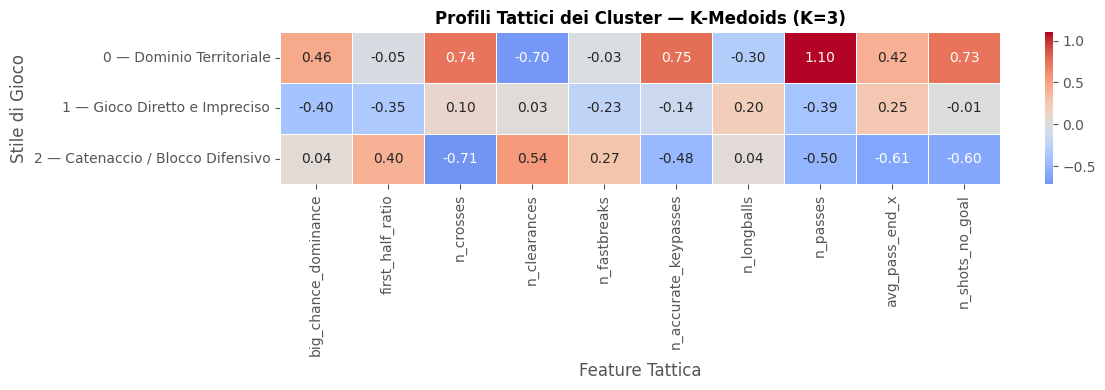

In [19]:
K_FINAL = 3
clusters, medoid_indices, _ = kmedoids(X_scaled, K_FINAL)

sil_final = silhouette_score(X_scaled, clusters, metric='euclidean')
print('=' * 55)
print(f'Silhouette Score finale — K-Medoids (K={K_FINAL}): {sil_final:.4f}')
print('=' * 55)

df_clustered['Cluster'] = clusters


cluster_names = {
    0: 'Dominio Territoriale',
    1: 'Gioco Diretto e Impreciso',
    2: 'Catenaccio / Blocco Difensivo'
}

df_scaled_profiles = pd.DataFrame(X_scaled, columns=X_num.columns)
df_scaled_profiles['Cluster'] = clusters
mean_profiles = df_scaled_profiles.groupby('Cluster').mean()

key_features = [
    'big_chance_dominance',
    'first_half_ratio',
    'n_crosses',
    'n_clearances',
    'n_fastbreaks',
    'n_accurate_keypasses',
    'n_longballs',
    'n_passes',
    'avg_pass_end_x',
     'n_shots_no_goal'
]


available_features = [f for f in key_features if f in mean_profiles.columns]

missing = [f for f in key_features if f not in mean_profiles.columns]
if missing:
    print(f'[ATTENZIONE] Feature non trovate: {missing} — verifica con list(X_num.columns)')

ytick_labels = [f"{i} — {cluster_names.get(i, 'Cluster ' + str(i))}" for i in mean_profiles.index]

plt.figure(figsize=(12, 4))
sns.heatmap(mean_profiles[available_features], annot=True, cmap='coolwarm',
            center=0, fmt='.2f', linewidths=0.5, yticklabels=ytick_labels)
plt.title('Profili Tattici dei Cluster — K-Medoids (K=3)', fontweight='bold', fontsize=12)
plt.xlabel('Feature Tattica')
plt.ylabel('Stile di Gioco')
plt.tight_layout()
plt.show()

### 5. Validazione Esterna: Struttura Tattica vs Esito della Partita

L'ultima e più importante fase di validazione è quella **esterna**. Fino ad ora l'algoritmo di clustering (K-Medoids) ha lavorato in modalità "cieca" (Non Supervisionata): ha raggruppato le squadre unicamente in base alle loro statistiche di gioco (passaggi, lanci lunghi, baricentro), ignorando completamente chi avesse vinto o perso.

Per verificare se questi "stili di gioco" geometricamente calcolati abbiano un reale peso sportivo, incrociamo i nostri Cluster con la variabile target reale (`outcome`: Vittoria, Sconfitta, Pareggio) usando una Tabella di Contingenza (Crosstab).

Se i cluster tattici sono validi, ci aspettiamo di vedere una distribuzione sbilanciata:
* Il cluster associato al **Dominio Territoriale** dovrebbe mostrare una percentuale di *Vittorie* nettamente superiore alla media.
* Il cluster associato al **Catenaccio o Passività** dovrebbe avere picchi di *Sconfitte* o *Pareggi*.

Questo confronto trasforma un freddo raggruppamento algoritmico in una vera e propria analisi di "Winning Strategy" calcistica.


In [20]:
print("=" * 65)
print("VALIDAZIONE ESTERNA: STRUTTURA GEOMETRICA vs ESITO REALE")
print("=" * 65)

crosstab = pd.crosstab(
    df_clustered['Cluster'],
    df_clustered['outcome'],
    normalize='index'
)
crosstab_pct = (crosstab * 100).round(1).astype(str) + '%'
print(crosstab_pct)

print("\nDistribuzione cluster:")
print(df_clustered['Cluster'].value_counts().sort_index())


VALIDAZIONE ESTERNA: STRUTTURA GEOMETRICA vs ESITO REALE
outcome   Draw   Loss    Win
Cluster                     
0        20.2%  33.0%  46.8%
1        21.3%  54.5%  24.2%
2        21.5%  29.1%  49.4%

Distribuzione cluster:
Cluster
0    218
1    277
2    265
Name: count, dtype: int64
